### Kütüphanler

In [7]:
import os
import yaml
import json
import logging
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
from datetime import datetime

# Stable Baselines3 ve Contrib
from stable_baselines3 import PPO
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.vec_env import SubprocVecEnv, VecMonitor, VecFrameStack, DummyVecEnv
from stable_baselines3.common.utils import set_random_seed

# Grafik Ayarları
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.style.use('seaborn-v0_8-whitegrid')

# Logger
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger("Thesis_Phase3")

# Donanım Seçimi (Mac MPS Desteği Dahil)
def get_optimal_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = get_optimal_device()
print(f"🚀 Donanım Hızlandırıcı: {DEVICE}")

🚀 Donanım Hızlandırıcı: mps


### Wrappers

In [8]:
# --- 1. Mac/MPS Uyumluluk Wrapper (Zorunlu) ---
class Float32ObservationWrapper(gym.ObservationWrapper):
    """Mac MPS'in float64 desteklememesi sorununu çözer. Tüm inputları float32 yapar."""
    def __init__(self, env):
        super().__init__(env)
        self.observation_space = gym.spaces.Box(
            low=env.observation_space.low,
            high=env.observation_space.high,
            shape=env.observation_space.shape,
            dtype=np.float32
        )
    def observation(self, observation):
        return np.array(observation, dtype=np.float32)

# --- 2. Fiziksel Manipülasyon (Fault Injection Ready) ---
class RandomDampingWrapper(gym.Wrapper):
    """
    Sürtünmeyi (Damping) değiştirir. 
    'set_damping' metodu sayesinde epizot ortasında (Reset atmadan) müdahale edilebilir.
    """
    def __init__(self, env, min_damping, max_damping):
        super().__init__(env)
        self.min_d = min_damping
        self.max_d = max_damping

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # Her epizot başında rastgele bir fizik katsayısı belirle (Domain Randomization)
        new_damping = self.np_random.uniform(self.min_d, self.max_d)
        self.set_damping(new_damping)
        return self.env.reset(seed=seed, options=options)

    def set_damping(self, value):
        """Dışarıdan veya anlık değişim (Sudden Fault) için çağrılır."""
        if hasattr(self.env.unwrapped, 'model'):
            dof_count = len(self.env.unwrapped.model.dof_damping)
            if isinstance(value, (float, int)):
                val_array = np.full(dof_count, value)
            else:
                val_array = value
            self.env.unwrapped.model.dof_damping[:] = val_array

# --- 3. Context Awareness (Previous Action) ---
class PreviousActionWrapper(gym.Wrapper):
    """
    Gözlem vektörüne bir önceki aksiyonu ekler.
    Input: [Obs_t] -> [Obs_t, Action_{t-1}]
    Bu sayede LSTM: "Ben X torku uyguladım ama Y kadar gittim, demek ki sürtünme Z" çıkarımını yapabilir.
    """
    def __init__(self, env):
        super().__init__(env)
        obs_space = env.observation_space
        act_space = env.action_space
        
        # Yeni observation space tanımı (Mevcut + Aksiyon Boyutu)
        low = np.concatenate([obs_space.low, act_space.low])
        high = np.concatenate([obs_space.high, act_space.high])
        
        self.observation_space = gym.spaces.Box(low=low, high=high, dtype=np.float32)
        self.prev_action = np.zeros(act_space.shape, dtype=np.float32)

    def reset(self, seed=None, options=None):
        obs, info = self.env.reset(seed=seed, options=options)
        self.prev_action = np.zeros(self.env.action_space.shape, dtype=np.float32)
        new_obs = np.concatenate([obs, self.prev_action]).astype(np.float32)
        return new_obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        new_obs = np.concatenate([obs, self.prev_action]).astype(np.float32)
        self.prev_action = action.astype(np.float32) # Bir sonraki adım için sakla
        return new_obs, reward, terminated, truncated, info

### Trainer

In [ ]:
# Notebook Hücresi: Scientific Trainer (Clean & Stable)
import os
import yaml
import json
import logging
import torch
import gymnasium as gym
import numpy as np
from datetime import datetime

# SB3
from stable_baselines3 import PPO
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.vec_env import SubprocVecEnv, VecMonitor, VecFrameStack
from stable_baselines3.common.utils import set_random_seed

# Local
from src.utils.device import get_optimal_device
# Wrapperlarınızın importları (yukarıdaki hücrede tanımlı olduklarını varsayıyorum)
# from src.envs.wrappers... import ...

class ScientificTrainer:
    def __init__(self, config_path: str):
        """
        Config dosyasını diskten okur, log klasörünü hazırlar.
        Tweak mekanizması iptal edildi.
        """
        self.logger = logging.getLogger("ScientificTrainer")
        self.logger.setLevel(logging.INFO)
        
        # 1. Config Dosyasını Oku (Single Source of Truth)
        if not os.path.exists(config_path):
            raise FileNotFoundError(f"❌ Config dosyası bulunamadı: {config_path}")
            
        with open(config_path) as f:
            self.config = yaml.safe_load(f)
            
        # 2. Run ID ve Klasör Yapısı
        self.timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        self.run_id = f"{self.config['experiment']['name']}_{self.timestamp}"
        self.device = get_optimal_device()
        
        # Log Klasörü (Notebook konumuna göre ../data/logs)
        self.log_dir = os.path.join("..", "data", "logs", self.run_id)
        os.makedirs(self.log_dir, exist_ok=True)
        
        # 3. Config'in Kopyasını Arşivle (Evidence)
        # Orijinal dosyayı değil, okuduğumuz içeriği JSON olarak dump ediyoruz.
        with open(os.path.join(self.log_dir, "config.json"), "w") as f:
            json.dump(self.config, f, indent=4)
            
        self.print_obsidian_header(config_path)

    def print_obsidian_header(self, original_path):
        print("\n" + "="*40)
        print("📋 OBSIDIAN LAB NOTE HEADER")
        print("="*40)
        print(f"run_id: \"{self.run_id}\"")
        print(f"source_config: \"{original_path}\"")
        print(f"device: \"{self.device}\"")
        print("="*40 + "\n")

    def _make_env_factory(self, seed, rank, wrapper_conf, force_cpu=False):
        def _init():
            env = gym.make(self.config['env']['id'])
            
            # Device Handling
            device_type = "cpu" if force_cpu else str(self.device)
            if device_type == "mps": 
                env = Float32ObservationWrapper(env)
            
            # Physics
            env = RandomDampingWrapper(
                env, 
                min_damping=wrapper_conf['min_damping'], 
                max_damping=wrapper_conf['max_damping']
            )
            # Context
            env = PreviousActionWrapper(env)
            
            env.reset(seed=seed + rank)
            return env
        return _init

    def train_variant(self, variant_name):
        print(f"\n{'='*60}")
        print(f"🚀 EĞİTİM BAŞLIYOR: {variant_name}")
        print(f"{'='*60}")
        
        seeds = self.config['training']['seeds']
        wrapper_conf = self.config['env']['wrappers'][0]['args']
        train_timesteps = self.config['training']['total_timesteps']
        
        trained_model_paths = []

        # Model Seçimi ve Parametre Temizliği
        if variant_name == "LSTM":
            ModelClass = RecurrentPPO
            policy_type = "MlpLstmPolicy"
            current_device = self.device
            force_cpu = False
            policy_kwargs = self.config['hyperparameters']['policy_kwargs']
            print(f"   🧠 Model: RecurrentPPO (GPU/MPS)")
        else:
            ModelClass = PPO
            policy_type = "MlpPolicy"
            current_device = "cpu" # MLP için CPU daha hızlı/stabil
            force_cpu = True
            # LSTM parametrelerini temizle
            base_kwargs = self.config['hyperparameters']['policy_kwargs'].copy()
            exclude = ['lstm_hidden_size', 'n_lstm_layers', 'shared_lstm', 'enable_critic_lstm']
            policy_kwargs = {k: v for k, v in base_kwargs.items() if k not in exclude}
            print(f"   🧠 Model: Standard PPO (CPU Optimized)")

        for seed in seeds:
            set_random_seed(seed)
            
            # Ortam Kurulumu
            env = SubprocVecEnv([
                self._make_env_factory(seed, i, wrapper_conf, force_cpu) 
                for i in range(self.config['env']['n_envs'])
            ])
            
            if variant_name == "FrameStack":
                env = VecFrameStack(env, n_stack=4)
                print(f"   🛠️ FrameStack: Aktif (4 frames)")
            
            env = VecMonitor(env, filename=os.path.join(self.log_dir, f"{variant_name}_seed_{seed}_monitor.csv"))
            
            model = ModelClass(
                policy=policy_type,
                env=env,
                verbose=1, # Tablo çıktısı için 1 olmalı
                device=current_device,
                tensorboard_log=self.log_dir,
                learning_rate=self.config['hyperparameters']['learning_rate'],
                n_steps=self.config['hyperparameters']['n_steps'],
                batch_size=self.config['hyperparameters']['batch_size'],
                gamma=self.config['hyperparameters']['gamma'],
                gae_lambda=self.config['hyperparameters']['gae_lambda'],
                ent_coef=self.config['hyperparameters']['ent_coef'],
                policy_kwargs=policy_kwargs
            )

            print(f"   🌱 Seed {seed} eğitiliyor... ({train_timesteps} steps)")
            
            # DÜZELTME: progress_bar=False yaptık. 
            # Ekran titremesini önlemek için sadece log tablosu basacak.
            model.learn(
                total_timesteps=train_timesteps, 
                tb_log_name=f"{variant_name}_seed_{seed}",
                progress_bar=False, 
                log_interval=10 # Her 10 update'de (20k adım) bir tablo basar, spam yapmaz.
            )
            
            save_path = os.path.join(self.log_dir, f"final_model_{variant_name}_seed_{seed}")
            model.save(save_path)
            trained_model_paths.append(save_path)
            print(f"   ✅ Model Kaydedildi: {save_path}")
            
            env.close()
            
        return trained_model_paths

### Config Oluşturma ve Training

In [10]:
# 1. Config Dosyasını Diske Yaz (Tekrarlanabilirlik İçin)
config_dir = "../configs/phase_3_1"
os.makedirs(config_dir, exist_ok=True)
config_path = os.path.join(config_dir, "reacher_experiment_final.yaml")

yaml_content = """
experiment:
  name: "Phase-3.1-Comparison"
  description: "Comparing Vanilla, FrameStack, and LSTM on Reacher-v5"

env:
  id: "Reacher-v5"
  n_envs: 2
  wrappers:
    - name: "RandomDampingWrapper"
      args: {min_damping: 0.5, max_damping: 2.0}

training:
  algo: "Mixed"
  total_timesteps: 500000  # Tez için bunu 500k veya 1M yapın
  seeds: [42] # Hızlı demo için tek seed, gerçekte [42, 43, 44] yapın

hyperparameters:
  policy_type: "MlpLstmPolicy" # veya MlpPolicy (Otomatik seçiliyor)
  learning_rate: 0.0003
  n_steps: 2048
  batch_size: 64
  gamma: 0.99
  gae_lambda: 0.95
  ent_coef: 0.01
  policy_kwargs:
    # Ortak MLP Ayarları
    net_arch: 
      pi: [64, 64]
      vf: [64, 64]
    # LSTM Ayarları (Sadece RecurrentPPO kullanır)
    lstm_hidden_size: 256
    n_lstm_layers: 1
    shared_lstm: False
    enable_critic_lstm: True
"""

with open(config_path, "w") as f:
    f.write(yaml_content)

# 2. Trainer'ı Başlat
trainer = ScientificTrainer(config_path)


2025-11-25 12:44:18,186 - INFO - 🚀 Apple Silicon (MPS) detected. Using Metal Performance Shaders.



📋 OBSIDIAN LAB NOTE HEADER
run_id: "Phase-3.1-Comparison_20251125_124418"
source_config: "../configs/phase_3_1/reacher_experiment_final.yaml"
device: "mps"



In [11]:

# 3. ÜÇ VARYASYONU DA EĞİT
# Çıktı olarak kaydedilen modellerin yollarını alıyoruz
paths_vanilla = trainer.train_variant("Vanilla")
print("\n🎉 PPO (Vanilla) Eğitimi BAŞARIYLA TAMAMLANDI.")


🚀 EĞİTİM BAŞLIYOR: Vanilla
   🧠 Model: Standard PPO (CPU Optimized)
Using cpu device
   🌱 Seed 42 eğitiliyor... (500000 steps)
Logging to ../data/logs/Phase-3.1-Comparison_20251125_124418/Vanilla_seed_42_1


/Users/berkaygurkan/pytorch_m1_env/lib/python3.9/site-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/berkaygurkan/pytorch_m1_env/lib/python3.9/site-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/berkaygurkan/pytorch_m1_env/lib/python3.9/site-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
/Users/berkaygurkan/pytorch_m1_env/lib/python3.9/site-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 50          |
|    ep_rew_mean          | -54.5       |
| time/                   |             |
|    fps                  | 3257        |
|    iterations           | 10          |
|    time_elapsed         | 12          |
|    total_timesteps      | 40960       |
| train/                  |             |
|    approx_kl            | 0.015395533 |
|    clip_fraction        | 0.142       |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.05       |
|    explained_variance   | 0.936       |
|    learning_rate        | 0.0003      |
|    loss                 | 4.2         |
|    n_updates            | 90          |
|    policy_gradient_loss | -0.0202     |
|    std                  | 0.659       |
|    value_loss           | 6.73        |
-----------------------------------------
-----------------------------------------
| rollout/                |       

In [12]:
paths_framestack = trainer.train_variant("FrameStack")


print("\n🎉 PPOFrameStack Eğitimi BAŞARIYLA TAMAMLANDI.")


🚀 EĞİTİM BAŞLIYOR: FrameStack
   🧠 Model: Standard PPO (CPU Optimized)
   🛠️ FrameStack: Aktif (4 frames)
Using cpu device
   🌱 Seed 42 eğitiliyor... (500000 steps)
Logging to ../data/logs/Phase-3.1-Comparison_20251125_124418/FrameStack_seed_42_1


/Users/berkaygurkan/pytorch_m1_env/lib/python3.9/site-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/berkaygurkan/pytorch_m1_env/lib/python3.9/site-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/berkaygurkan/pytorch_m1_env/lib/python3.9/site-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
/Users/berkaygurkan/pytorch_m1_env/lib/python3.9/site-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 50          |
|    ep_rew_mean          | -49.7       |
| time/                   |             |
|    fps                  | 2885        |
|    iterations           | 10          |
|    time_elapsed         | 14          |
|    total_timesteps      | 40960       |
| train/                  |             |
|    approx_kl            | 0.014693832 |
|    clip_fraction        | 0.114       |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.02       |
|    explained_variance   | 0.845       |
|    learning_rate        | 0.0003      |
|    loss                 | 1.88        |
|    n_updates            | 90          |
|    policy_gradient_loss | -0.0185     |
|    std                  | 0.648       |
|    value_loss           | 5.03        |
-----------------------------------------
-----------------------------------------
| rollout/                |       

In [13]:
paths_lstm = trainer.train_variant("LSTM")
print("\n🎉 LSTM augmented obs Eğitimi BAŞARIYLA TAMAMLANDI.")


🚀 EĞİTİM BAŞLIYOR: LSTM
   🧠 Model: RecurrentPPO (GPU/MPS)
Using mps device
   🌱 Seed 42 eğitiliyor... (500000 steps)
Logging to ../data/logs/Phase-3.1-Comparison_20251125_124418/LSTM_seed_42_1


/Users/berkaygurkan/pytorch_m1_env/lib/python3.9/site-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/berkaygurkan/pytorch_m1_env/lib/python3.9/site-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/berkaygurkan/pytorch_m1_env/lib/python3.9/site-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
/Users/berkaygurkan/pytorch_m1_env/lib/python3.9/site-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 50          |
|    ep_rew_mean          | -41.2       |
| time/                   |             |
|    fps                  | 54          |
|    iterations           | 10          |
|    time_elapsed         | 752         |
|    total_timesteps      | 40960       |
| train/                  |             |
|    approx_kl            | 0.020773247 |
|    clip_fraction        | 0.101       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.92       |
|    explained_variance   | -2.1e-05    |
|    learning_rate        | 0.0003      |
|    loss                 | 0.419       |
|    n_updates            | 90          |
|    policy_gradient_loss | -0.0195     |
|    std                  | 0.61        |
|    value_loss           | 3.33        |
-----------------------------------------
----------------------------------------
| rollout/                |        

### Tensorboard Logs

📂 Loglar Analiz Ediliyor: ../data/logs/Phase-3.1-Comparison_20251125_124418


/var/folders/4n/h53cm6q91g98gmfnx47w5_200000gn/T/ipykernel_5840/2419862074.py:57: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_json(json.dumps(data)) # Hızlı dönüşüm


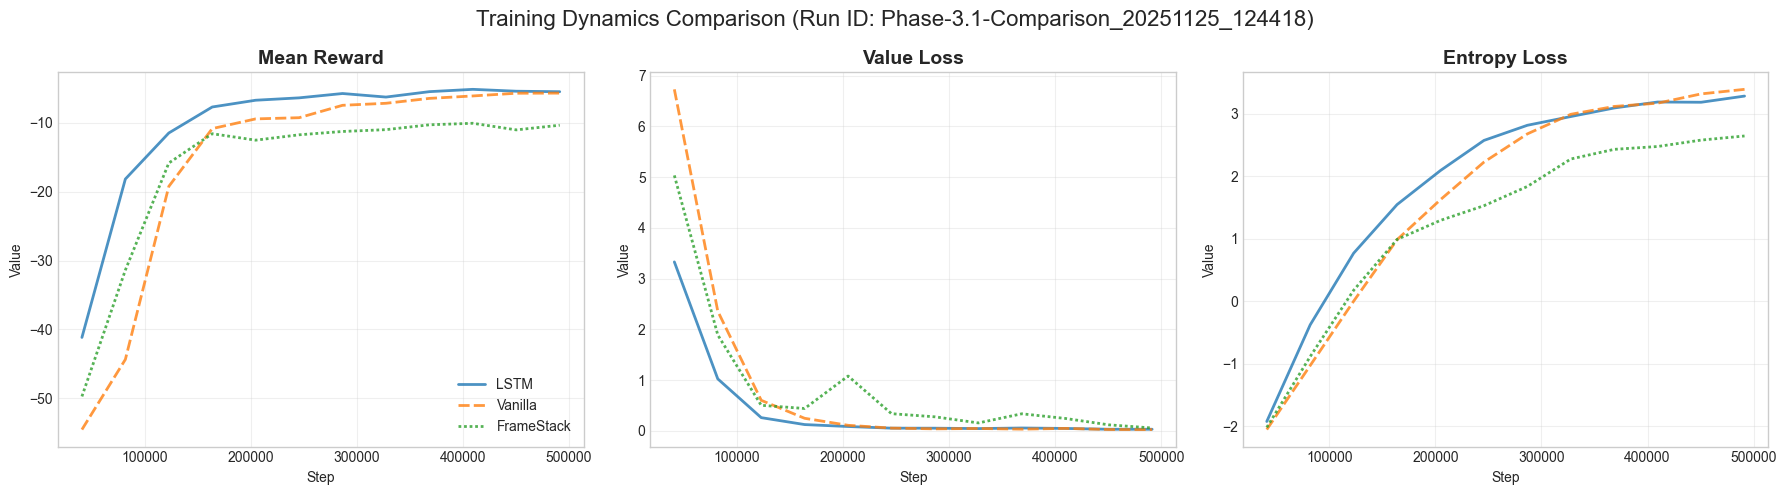

In [15]:
from tensorboard.backend.event_processing import event_accumulator
import pandas as pd
import seaborn as sns

def plot_tensorboard_logs(log_dir):
    """
    Tensorboard loglarını okur ve Matplotlib ile karşılaştırmalı çizer.
    """
    print(f"📂 Loglar Analiz Ediliyor: {log_dir}")
    
    # Aranacak metrikler (Tagler)
    metrics_map = {
        "rollout/ep_rew_mean": "Mean Reward",
        "train/value_loss": "Value Loss",
        "train/entropy_loss": "Entropy Loss"
    }
    
    # Veri havuzu
    data = []
    
    # Klasörleri gez
    for root, dirs, files in os.walk(log_dir):
        for file in files:
            if "events.out.tfevents" in file:
                # Model ismini klasör yolundan çıkar
                # Örnek: .../Vanilla_seed_42_1/events... -> Vanilla
                path_parts = root.split(os.sep)
                run_name = path_parts[-1]
                
                # Varyasyon adını temizle (örn: Vanilla_seed_42 -> Vanilla)
                if "Vanilla" in run_name: variant = "Vanilla"
                elif "FrameStack" in run_name: variant = "FrameStack"
                elif "LSTM" in run_name: variant = "LSTM"
                else: continue # Bilinmeyen klasörleri atla

                # Event dosyasını oku
                ea = event_accumulator.EventAccumulator(
                    os.path.join(root, file),
                    size_guidance={event_accumulator.SCALARS: 0} # Tüm datayı oku
                )
                ea.Reload()
                
                # Metrikleri çek
                for tag, nice_name in metrics_map.items():
                    if tag in ea.Tags()['scalars']:
                        events = ea.Scalars(tag)
                        for event in events:
                            data.append({
                                "Step": event.step,
                                "Value": event.value,
                                "Metric": nice_name,
                                "Model": variant,
                                "Run": run_name # Seed ayrımı için
                            })

    # DataFrame oluştur
    df = pd.read_json(json.dumps(data)) # Hızlı dönüşüm
    
    if df.empty:
        print("⚠️ Hata: Hiçbir log verisi bulunamadı. Eğitim tamamlandı mı?")
        return

    # --- GRAFİK ÇİZİMİ ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    unique_metrics = list(metrics_map.values())
    
    for i, metric in enumerate(unique_metrics):
        sns.lineplot(
            data=df[df["Metric"] == metric],
            x="Step", y="Value", hue="Model", style="Model",
            ax=axes[i], linewidth=2, alpha=0.8
        )
        axes[i].set_title(metric, fontsize=14, fontweight='bold')
        axes[i].grid(True, alpha=0.3)
        # Reward grafiğini daha belirgin yap
        if metric == "Mean Reward":
            axes[i].legend(loc="lower right")
        else:
            axes[i].get_legend().remove()

    plt.suptitle(f"Training Dynamics Comparison (Run ID: {os.path.basename(log_dir)})", fontsize=16)
    plt.tight_layout()
    plt.show()

# Fonksiyonu Çalıştır
plot_tensorboard_logs(trainer.log_dir)

### OOD Test


🧪 OOD TEST BAŞLIYOR (Ağır Sürtünme: Damping 3.0 - 5.0)
   ► Testing: Vanilla...
     ❌ HATA: Vanilla yüklenemedi. Observation spaces do not match: Box([-inf -inf -inf -inf -inf -inf -inf -inf -inf -inf  -1.  -1.], [inf inf inf inf inf inf inf inf inf inf  1.  1.], (12,), float32) != Box(-inf, inf, (12,), float32)
   ► Testing: FrameStack...
     ❌ HATA: FrameStack yüklenemedi. Observation spaces do not match: Box([-inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf
 -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf
 -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf  -1.  -1.
  -1.  -1.  -1.  -1.  -1.  -1.], [inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf
 inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf
 inf inf inf inf  1.  1.  1.  1.  1.  1.  1.  1.], (48,), float32) != Box(-inf, inf, (48,), float32)
   ► Testing: LSTM...
     ❌ HATA: LSTM yüklenemedi. Observation spaces do not match: Box

/var/folders/4n/h53cm6q91g98gmfnx47w5_200000gn/T/ipykernel_5840/1589750295.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results.values(), labels=results.keys(), patch_artist=True,


ValueError: Dimensions of labels and X must be compatible

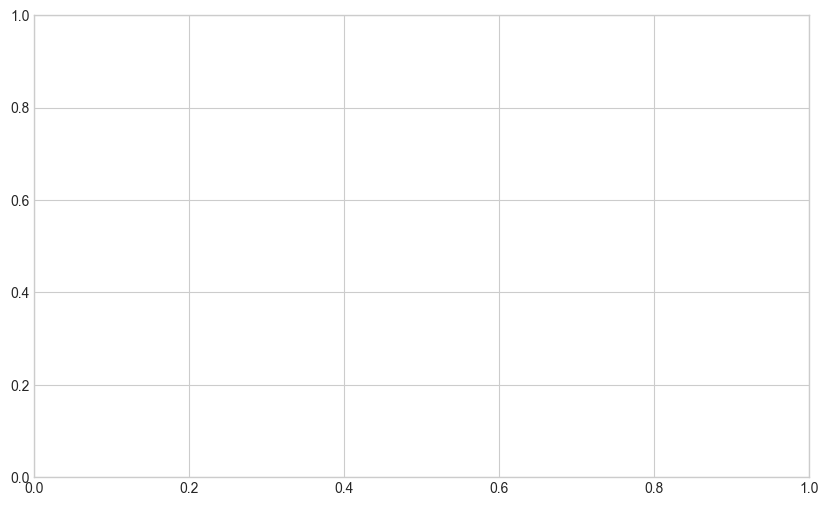

In [29]:
# HÜCRE 6: Test 1 - OOD Generalization (Metrics & Plot)

def evaluate_ood_compare(models_map, n_episodes=30):
    """
    Modelleri eğitimde görülmemiş fiziksel koşullarda test eder ve istatistikleri raporlar.
    """
    # 1. OOD Ortam Kurulumu: Damping [3.0, 5.0] (Eğitimde [0.5, 2.0] idi)
    def make_ood_env():
        env = gym.make("Reacher-v5") 
        env = Float32ObservationWrapper(env)
        env = RandomDampingWrapper(env, min_damping=3.0, max_damping=5.0) # <-- OOD Range
        
        # Augmented/PreviousAction Wrapper
        # NOT: Modeliniz hangisiyle eğitildiyse onu kullanın. 
        # Son çalışan kodda 'PreviousActionWrapper' kullanmıştık.
        env = PreviousActionWrapper(env) 
        return env

    env_base = DummyVecEnv([make_ood_env])
    results = {}
    
    print(f"\n{'='*60}")
    print(f"🧪 OOD TEST BAŞLIYOR (Ağır Sürtünme: Damping 3.0 - 5.0)")
    print(f"{'='*60}")
    
    # 2. Test Döngüsü
    for name, path in models_map.items():
        print(f"   ► Testing: {name}...")
        
        # FrameStack ayarı
        if name == "FrameStack":
            eval_env = VecFrameStack(env_base, n_stack=4)
        else:
            eval_env = env_base
            # Varsa eski stack wrapper'ı temizle
            if hasattr(eval_env, 'stack_frames'): eval_env = env_base 

        # Model Yükleme
        try:
            if name == "LSTM":
                model = RecurrentPPO.load(path, env=eval_env, device="cpu")
            else:
                model = PPO.load(path, env=eval_env, device="cpu")
        except Exception as e:
            print(f"     ❌ HATA: {name} yüklenemedi. {e}")
            continue
            
        # Epizotları Çalıştır
        scores = []
        for _ in range(n_episodes):
            obs = eval_env.reset()
            done = False
            total_reward = 0
            lstm_states = None
            starts = np.ones((1,), dtype=bool)
            
            while not done:
                if name == "LSTM":
                    action, lstm_states = model.predict(obs, state=lstm_states, episode_start=starts, deterministic=True)
                else:
                    action, _ = model.predict(obs, deterministic=True)
                
                obs, reward, done, _ = eval_env.step(action)
                total_reward += reward[0]
                starts = done
            scores.append(total_reward)
        results[name] = scores

    # 3. Görselleştirme (Box Plot)
    plt.figure(figsize=(10, 6))
    plt.boxplot(results.values(), labels=results.keys(), patch_artist=True, 
                boxprops=dict(facecolor="lightblue", color="blue"),
                medianprops=dict(color="red", linewidth=1.5))
    plt.title(f"OOD Generalization Gap (Unseen Friction)\nBased on {n_episodes} Episodes", fontsize=14)
    plt.ylabel("Total Reward (Higher is Better)")
    plt.grid(True, alpha=0.3)
    plt.show()

    # 4. İSTATİSTİKSEL RAPOR (TABLO)
    print("\n📊 OOD PERFORMANS METRİKLERİ")
    print("-" * 75)
    print(f"{'Model':<15} | {'Mean Reward':<12} | {'Std Dev':<10} | {'Min':<8} | {'Max':<8}")
    print("-" * 75)
    
    stats_data = []
    
    for name, scores in results.items():
        mean_score = np.mean(scores)
        std_score = np.std(scores)
        min_score = np.min(scores)
        max_score = np.max(scores)
        
        # Tabloya Yazdır
        print(f"{name:<15} | {mean_score:10.2f}   | {std_score:8.2f}   | {min_score:8.1f} | {max_score:8.1f}")
        
        # Veri toplama (DataFrame için)
        stats_data.append({
            "Model": name,
            "Mean": mean_score,
            "Std": std_score,
            "Min": min_score,
            "Max": max_score
        })
        
    print("-" * 75)
    
    # Pandas DataFrame döndür (Analiz için)
    return pd.DataFrame(stats_data)

# --- TESTİ BAŞLAT ---
if 'paths_vanilla' in locals():
    models_map = {
        "Vanilla": paths_vanilla[0],
        "FrameStack": paths_framestack[0],
        "LSTM": paths_lstm[0]
    }
    df_results = evaluate_ood_compare(models_map, n_episodes=50) # 50 Epizotluk Test
    
    # Not: df_results.to_csv("ood_results.csv") diyerek kaydedebilirsiniz.
else:
    print("⚠️ Model yolları bulunamadı. Lütfen eğitim hücresini çalıştırın.")

### Sudden Change Test

⚡ Sudden Fault Test: Vanilla
⚡ Sudden Fault Test: FrameStack
⚡ Sudden Fault Test: LSTM
   -> ⚠️ ANİ ARIZA: Damping 1.0 -> 5.0


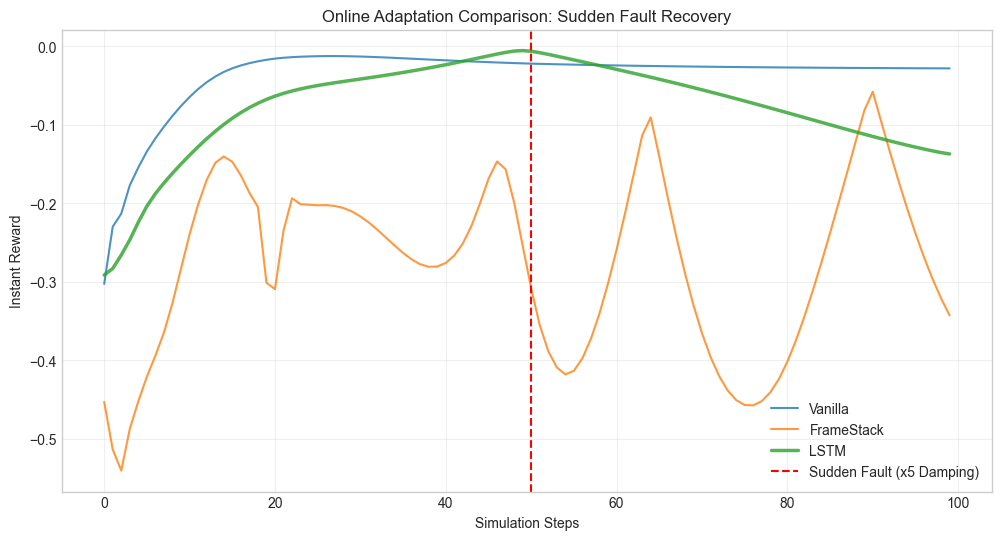

In [30]:
# Gerekli Kütüphaneler
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
from stable_baselines3 import PPO
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack

# ==========================================
# 1. GEREKLİ WRAPPER TANIMLARI
# ==========================================

class Float32ObservationWrapper(gym.ObservationWrapper):
    """Mac MPS ve GPU uyumluluğu için."""
    def __init__(self, env):
        super().__init__(env)
        self.observation_space = gym.spaces.Box(
            low=env.observation_space.low,
            high=env.observation_space.high,
            shape=env.observation_space.shape,
            dtype=np.float32
        )
    def observation(self, observation):
        return np.array(observation, dtype=np.float32)


class RandomDampingWrapper(gym.Wrapper):
    """
    Sürtünmeyi değiştirir. 'set_damping' metodunu dışarı açar.
    """
    def __init__(self, env, min_damping, max_damping):
        super().__init__(env)
        self.min_d = min_damping
        self.max_d = max_damping

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        new_damping = self.np_random.uniform(self.min_d, self.max_d)
        self.set_damping(new_damping)
        return self.env.reset(seed=seed, options=options)

    def set_damping(self, value):
        # Reacher-v5 / MuJoCo Binding
        if hasattr(self.env.unwrapped, 'model'):
            dof_count = len(self.env.unwrapped.model.dof_damping)
            if isinstance(value, (float, int)):
                val_array = np.full(dof_count, value)
            else:
                val_array = value
            self.env.unwrapped.model.dof_damping[:] = val_array


class PreviousActionWrapper(gym.Wrapper):
    """
    [FIXED] Modeliniz bu wrapper ile eğitildiği için TESTTE DE BU KULLANILMALI.
    Girdi: [Obs + Action]
    """
    def __init__(self, env):
        super().__init__(env)
        obs_space = env.observation_space
        act_space = env.action_space
        
        # Yeni boyut = Obs + Action
        new_shape = (old_shape := obs_space.shape[0]) + act_space.shape[0]
        
        self.observation_space = gym.spaces.Box(
            low=-np.inf, high=np.inf, shape=(new_shape,), dtype=np.float32
        )
        self.prev_action = np.zeros(act_space.shape[0], dtype=np.float32)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.prev_action = np.zeros_like(self.prev_action)
        return self._get_obs(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        # Buffer güncelle
        aug_obs = self._get_obs(obs)
        self.prev_action = action.astype(np.float32)
        return aug_obs, reward, terminated, truncated, info

    def _get_obs(self, current_obs):
        return np.concatenate([current_obs, self.prev_action]).astype(np.float32)


# ==========================================
# 2. TEST FONKSİYONU (Shape & Attribute Fix)
# ==========================================

def test_sudden_change_compare(models_map):
    plt.figure(figsize=(12, 6))
    
    # A. Ortam Zincirini Kur
    # 1. Çekirdek Ortam (Reacher-v5)
    env_core = gym.make("Reacher-v5", max_episode_steps=150)
    env_float = Float32ObservationWrapper(env_core)
    
    # 2. Fizik Kontrolcüsü (Referansı saklıyoruz!)
    physics_controller = RandomDampingWrapper(env_float, 0.5, 2.0)
    
    # 3. Input Formatlayıcı (Modelin beklediği şekil: Obs + Action)
    env_final = PreviousActionWrapper(physics_controller)
    
    for name, path in models_map.items():
        print(f"⚡ Sudden Fault Test: {name}")
        
        # B. DummyVecEnv Oluştur
        if name == "FrameStack":
            env = DummyVecEnv([lambda: env_final]) 
            env = VecFrameStack(env, n_stack=4)
        else:
            env = DummyVecEnv([lambda: env_final])

        # C. Modeli Yükle (CPU'da test etmek daha güvenli)
        try:
            if name == "LSTM": 
                model = RecurrentPPO.load(path, device="cpu")
            else: 
                model = PPO.load(path, device="cpu")
        except Exception as e:
            print(f"❌ Model yüklenemedi ({name}): {e}")
            continue
            
        # D. Test Başlangıcı
        obs = env.reset()
        
        # [FIX] env.unwrapped yerine sakladığımız physics_controller'ı kullanıyoruz
        physics_controller.set_damping(1.0) # Normal Başlangıç
        
        rewards = []
        lstm_states = None
        starts = np.ones((1,), dtype=bool)
        
        # E. 100 Adımlık Simülasyon
        for t in range(100):
            # --- ANİ ARIZA (t=50) ---
            if t == 50: 
                physics_controller.set_damping(5.0) # AĞIR SÜRTÜNME
                if name == "LSTM": print("   -> ⚠️ ANİ ARIZA: Damping 1.0 -> 5.0")
            
            # Tahmin
            if name == "LSTM":
                action, lstm_states = model.predict(obs, state=lstm_states, episode_start=starts, deterministic=True)
            else:
                action, _ = model.predict(obs, deterministic=True)
            
            # Adım
            obs, reward, done, _ = env.step(action)
            rewards.append(reward[0])
            
            # Reset gelirse state'i sıfırlamadan devam et (Adaptasyonu görmek için)
            if done:
                starts = np.ones((1,), dtype=bool)
                
        plt.plot(rewards, label=name, linewidth=2.5 if name=="LSTM" else 1.5, alpha=0.8)

    plt.axvline(x=50, color='r', linestyle='--', label="Sudden Fault (x5 Damping)")
    

#[Image of Box Plot]

    plt.title("Online Adaptation Comparison: Sudden Fault Recovery")
    plt.xlabel("Simulation Steps")
    plt.ylabel("Instant Reward")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Testi Başlat
# Not: paths_vanilla vb. değişkenlerin hafızada olduğundan emin olun
if 'paths_vanilla' in locals():
    models_map = {
        "Vanilla": paths_vanilla[0],
        "FrameStack": paths_framestack[0],
        "LSTM": paths_lstm[0]
    }
    test_sudden_change_compare(models_map)
else:
    print("⚠️ Model yolları bulunamadı, lütfen eğitim hücresini çalıştırın.")